In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
plt.figure(facecolor='black')
sns.set_style("dark")

<Figure size 640x480 with 0 Axes>

In [3]:
# Data Loading
data=pd.read_csv("apy.csv")
data.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [4]:
data.shape

(246091, 7)

In [5]:
data.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [7]:
data.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [8]:
data.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [9]:
data['State_Name'].unique()

array(['Andaman and Nicobar Islands', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat',
       'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand',
       'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

In [10]:
data['Crop'].unique()

array(['Arecanut', 'Other Kharif pulses', 'Rice', 'Banana', 'Cashewnut',
       'Coconut ', 'Dry ginger', 'Sugarcane', 'Sweet potato', 'Tapioca',
       'Black pepper', 'Dry chillies', 'other oilseeds', 'Turmeric',
       'Maize', 'Moong(Green Gram)', 'Urad', 'Arhar/Tur', 'Groundnut',
       'Sunflower', 'Bajra', 'Castor seed', 'Cotton(lint)', 'Horse-gram',
       'Jowar', 'Korra', 'Ragi', 'Tobacco', 'Gram', 'Wheat', 'Masoor',
       'Sesamum', 'Linseed', 'Safflower', 'Onion', 'other misc. pulses',
       'Samai', 'Small millets', 'Coriander', 'Potato',
       'Other  Rabi pulses', 'Soyabean', 'Beans & Mutter(Vegetable)',
       'Bhindi', 'Brinjal', 'Citrus Fruit', 'Cucumber', 'Grapes', 'Mango',
       'Orange', 'other fibres', 'Other Fresh Fruits', 'Other Vegetables',
       'Papaya', 'Pome Fruit', 'Tomato', 'Rapeseed &Mustard', 'Mesta',
       'Cowpea(Lobia)', 'Lemon', 'Pome Granet', 'Sapota', 'Cabbage',
       'Peas  (vegetable)', 'Niger seed', 'Bottle Gourd', 'Sannhamp',
       'Va

In [11]:
data['Crop_Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2010, 1997, 1998, 1999,
       2007, 2008, 2009, 2011, 2012, 2013, 2014, 2015])

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data[data['Production'].isnull()]

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
46,Andaman and Nicobar Islands,NICOBARS,2005,Whole Year,Arecanut,795.67,NaN
51,Andaman and Nicobar Islands,NICOBARS,2005,Whole Year,Dry chillies,17.00,NaN
623,Andhra Pradesh,ANANTAPUR,2007,Kharif,Moong(Green Gram),1000.00,NaN
630,Andhra Pradesh,ANANTAPUR,2007,Rabi,Horse-gram,1000.00,NaN
698,Andhra Pradesh,ANANTAPUR,2009,Rabi,Rapeseed &Mustard,8.00,NaN
...,...,...,...,...,...,...,...
244128,West Bengal,MEDINIPUR WEST,2010,Rabi,Peas & beans (Pulses),2.00,NaN
244581,West Bengal,MURSHIDABAD,2006,Kharif,Moong(Green Gram),200.00,NaN
245606,West Bengal,PURULIA,2001,Rabi,Rapeseed &Mustard,427.00,NaN
245644,West Bengal,PURULIA,2002,Rabi,Rapeseed &Mustard,522.00,NaN


In [14]:
data=data.dropna(subset=['Production'])
data.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242361 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     242361 non-null  object 
 1   District_Name  242361 non-null  object 
 2   Crop_Year      242361 non-null  int64  
 3   Season         242361 non-null  object 
 4   Crop           242361 non-null  object 
 5   Area           242361 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 14.8+ MB


In [16]:
data = data[data['Area'] > 0]
data['Yield'] = data['Production'] / data['Area']

Data PreParation

In [17]:
state_production=data.groupby('State_Name')['Production'].sum().reset_index()

In [18]:
year_production=data.groupby('Crop_Year')['Production'].sum().reset_index()

In [19]:
crop_production=data.groupby('Crop')['Production'].sum().reset_index()

In [20]:
season_production=data.groupby('Season')['Production'].sum().reset_index()

In [21]:
top_sate=state_production.sort_values(by='Production',ascending=False)
crop_prod=crop_production.sort_values(by='Production',ascending=False)

In [22]:
state_yield = data.groupby('State_Name')['Yield'].mean().reset_index()
state_yield

,State_Name,Yield
0,Andaman and Nicobar Islands,343.553142
1,Andhra Pradesh,195.138587
2,Arunachal Pradesh,3.647129
3,Assam,148.630468
4,Bihar,3.509814
5,Chandigarh,7.827887
6,Chhattisgarh,2.179586
7,Dadra and Nagar Haveli,7.503857
8,Goa,199.160564
9,Gujarat,5.716671


VISUALIZATIONS

C:\Users\hp\AppData\Local\Temp\ipykernel_23080\3312239156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Production',y='State_Name',data=top_states,palette='magma')


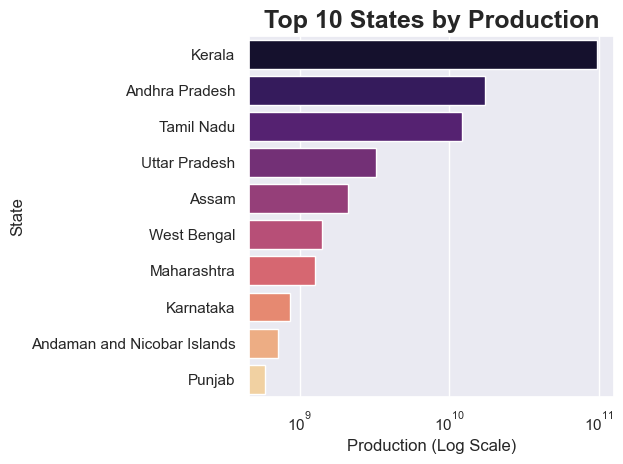

In [23]:
# Top States
plt.style.use("dark_background")
sns.set_theme()
top_states = state_production.sort_values(by='Production', ascending=False).head(10)
sns.barplot(x='Production',y='State_Name',data=top_states,palette='magma')
plt.xscale('log')
plt.title("Top 10 States by Production", fontsize=18, weight='bold')
plt.xlabel("Production (Log Scale)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Top 10 States by Production

This bar chart shows the top 10 states based on total crop production.

- The x-axis represents production (on a logarithmic scale to handle large variations).
- The y-axis represents the state names.

Insight:
- A few states contribute significantly higher production compared to others.
- The log scale helps visualize differences clearly despite large value ranges.

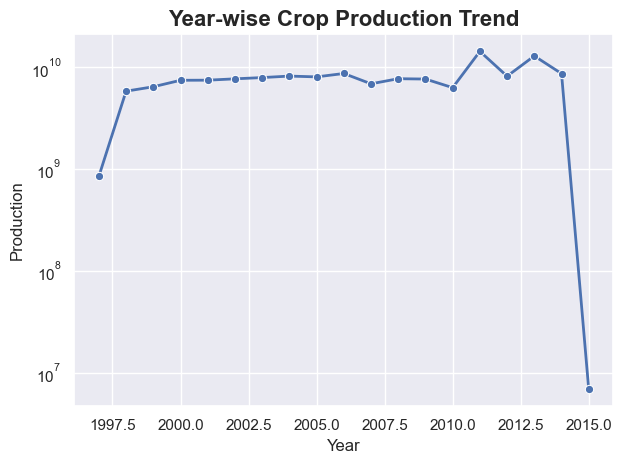

In [24]:
# Year Trend
sns.lineplot(x='Crop_Year', y='Production', data=year_production, marker='o', linewidth=2)
plt.title("Year-wise Crop Production Trend", fontsize=16, weight='bold')
plt.yscale('log')
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.tight_layout()
plt.show()

Year-wise Crop Production Trend

This line plot represents how total crop production has changed over the years.

- The x-axis shows the crop year.
- The y-axis shows total production.

Insight:
- We can observe trends such as growth, decline, or fluctuations in agricultural output.
- Helps identify peak production years and possible external impacts (weather, policies, etc.).

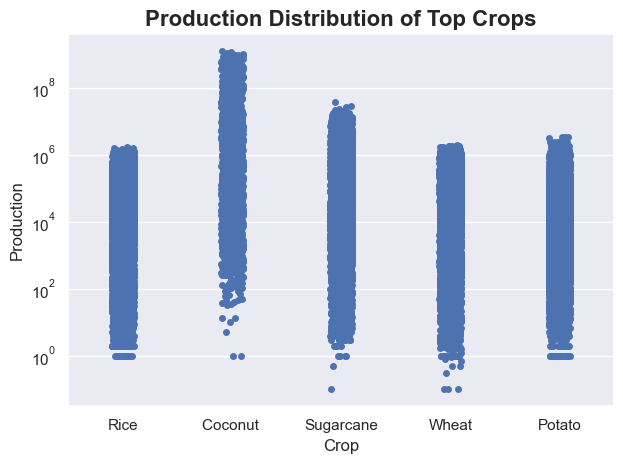

In [25]:
top5 = crop_production.sort_values(by='Production', ascending=False).head(5)
top_crops = data[data['Crop'].isin(top5['Crop'])]
sns.stripplot(x='Crop', y='Production', data=top_crops, jitter=True)
plt.title("Production Distribution of Top Crops", fontsize=16, weight='bold')
plt.yscale('log')
plt.xlabel("Crop")
plt.ylabel("Production")
plt.tight_layout()
plt.show()


Production Distribution of Top Crops

This strip plot shows the distribution of production values for the top 5 crops.

- Each dot represents a production value.
- Log scale is used due to high variation in production.

Insight:
- Some crops have very wide production ranges.
- Presence of outliers indicates variability in yield across regions or years.

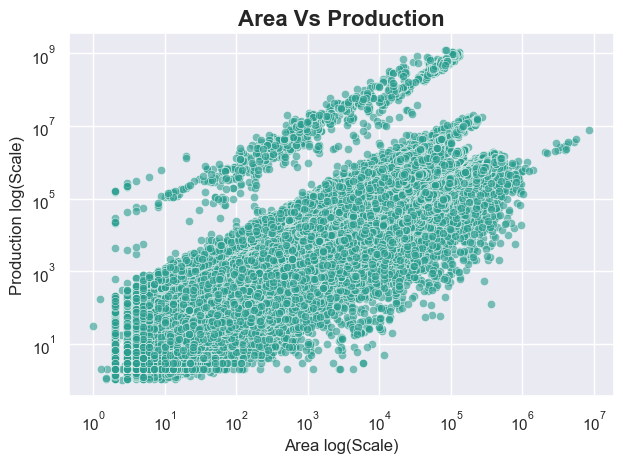

In [26]:
filtered_data = data[(data['Area'] > 1) & (data['Production'] > 1)]
sns.scatterplot(x='Area', y='Production', data=filtered_data, alpha=0.6, color='#2a9d8f')
plt.title("Area Vs Production", fontsize=16, weight='bold');
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Area log(Scale)")
plt.ylabel("Production log(Scale)")
plt.tight_layout()
plt.show()

Relationship between Area and Production

This scatter plot shows how cultivated area relates to production.

- Both axes are in log scale for better visualization.
- Each point represents a data record.

Insight:
- There is a positive relationship between area and production.
- However, spread indicates efficiency differences (same area ≠ same production).

C:\Users\hp\AppData\Local\Temp\ipykernel_23080\2914936761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Yield', y='State_Name', data=top_states_yield, palette='coolwarm')


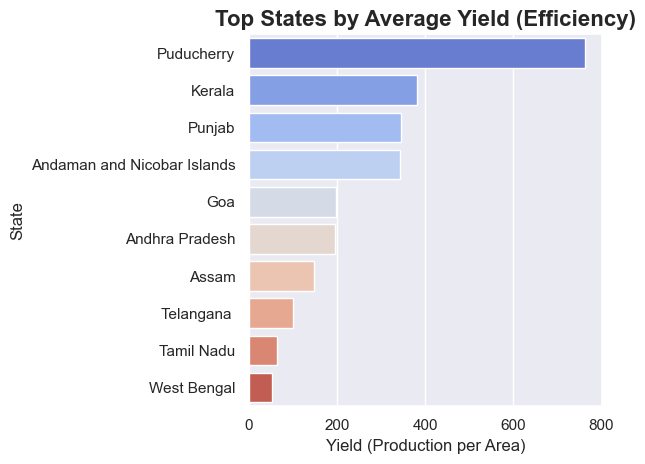

In [27]:
top_states_yield = state_yield.sort_values(by='Yield', ascending=False).head(10)
sns.barplot(x='Yield', y='State_Name', data=top_states_yield, palette='coolwarm')
plt.title("Top States by Average Yield (Efficiency)", fontsize=16, weight='bold')
plt.xlabel("Yield (Production per Area)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Top States by Average Yield

This bar chart represents states with the highest agricultural efficiency.

- Yield = Production / Area.
- Higher yield means better productivity per unit area.

Insight:
- Some smaller states outperform larger ones in efficiency.
- Indicates better farming practices or crop suitability.

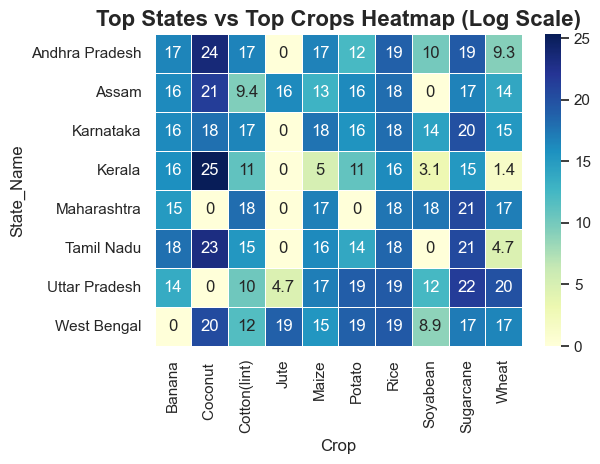

In [28]:
top_states = top_sate.head(8)['State_Name']
top_crops = crop_prod.head(10)['Crop']
pivot = data[(data['State_Name'].isin(top_states)) &(data['Crop'].isin(top_crops))
].pivot_table(values='Production',index='State_Name',columns='Crop',aggfunc='sum',fill_value=0)
sns.heatmap(np.log1p(pivot), cmap='YlGnBu', annot=True, linewidths=0.5)  
plt.title("Top States vs Top Crops Heatmap (Log Scale)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

Heatmap: Top States vs Top Crops

This heatmap shows production levels of top crops across top states.

- Rows represent states.
- Columns represent crops.
- Color intensity indicates production (log scale applied).

Insight:
- Helps identify which states dominate which crops.
- Shows specialization patterns in agriculture.

C:\Users\hp\AppData\Local\Temp\ipykernel_23080\2030235841.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered, x='Crop', y='Yield', palette='Set3')


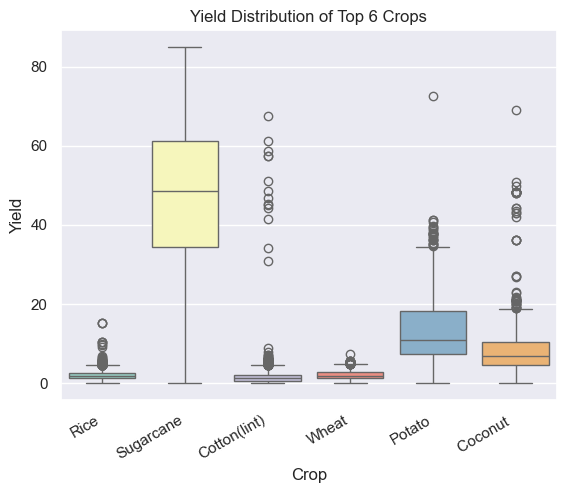

In [29]:
top6c = data.groupby('Crop')['Production'].sum().nlargest(6).index
filtered = data[data['Crop'].isin(top6c)]
filtered = filtered[filtered['Yield'] < filtered['Yield'].quantile(0.95)]
sns.boxplot(data=filtered, x='Crop', y='Yield', palette='Set3')
plt.title('Yield Distribution of Top 6 Crops')
plt.xticks(rotation=30, ha='right')
plt.show()

Yield Distribution of Top Crops

This boxplot shows the distribution of yield for top 6 crops.

- Displays median, quartiles, and outliers.
- Outliers beyond 95th percentile were removed for clarity.

Insight
- Some crops have consistent yields, while others show high variability.
- Useful for comparing crop stability and reliability.

ML Model

MAE : 0.66
MSE : 0.93
RMSE: 0.96
R2 Score: 0.91

Sample Predictions (Actual vs Predicted):
Actual: 794.00 | Predicted: 461.99
Actual: 5205.00 | Predicted: 11850.42
Actual: 30.00 | Predicted: 33.05
Actual: 1060.67 | Predicted: 1035.47
Actual: 12544.00 | Predicted: 5865.19


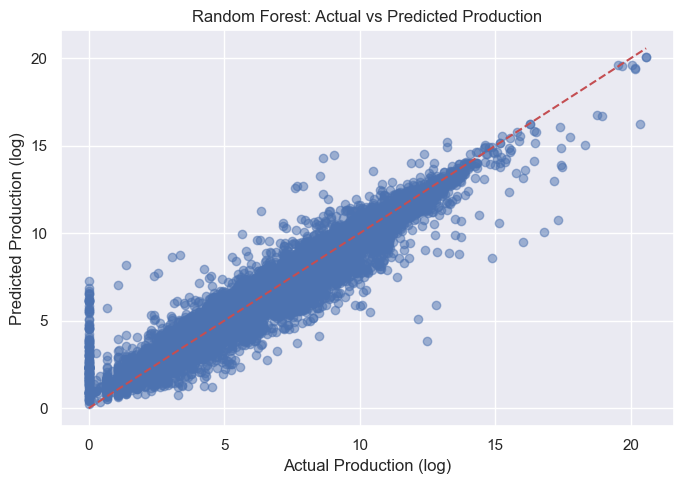

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

df = data.copy()
df = df.sample(50000, random_state=42)
le_state = LabelEncoder()
le_crop = LabelEncoder()
le_season = LabelEncoder()

df['State_Name'] = le_state.fit_transform(df['State_Name'])
df['Crop'] = le_crop.fit_transform(df['Crop'])
df['Season'] = le_season.fit_transform(df['Season'])

X = df[['State_Name', 'Crop', 'Season', 'Crop_Year', 'Area']]
y = np.log1p(df['Production'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

print("\nSample Predictions (Actual vs Predicted):")
for i in range(5):
    print(f"Actual: {y_test_actual.iloc[i]:.2f} | Predicted: {y_pred_actual[i]:.2f}")
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Production (log)")
plt.ylabel("Predicted Production (log)")
plt.title("Random Forest: Actual vs Predicted Production")
plt.grid(True)
plt.tight_layout()
plt.show()